(1731, 2365)


MemoryError: Unable to allocate 15.6 MiB for an array with shape (1731, 2363) and data type float32

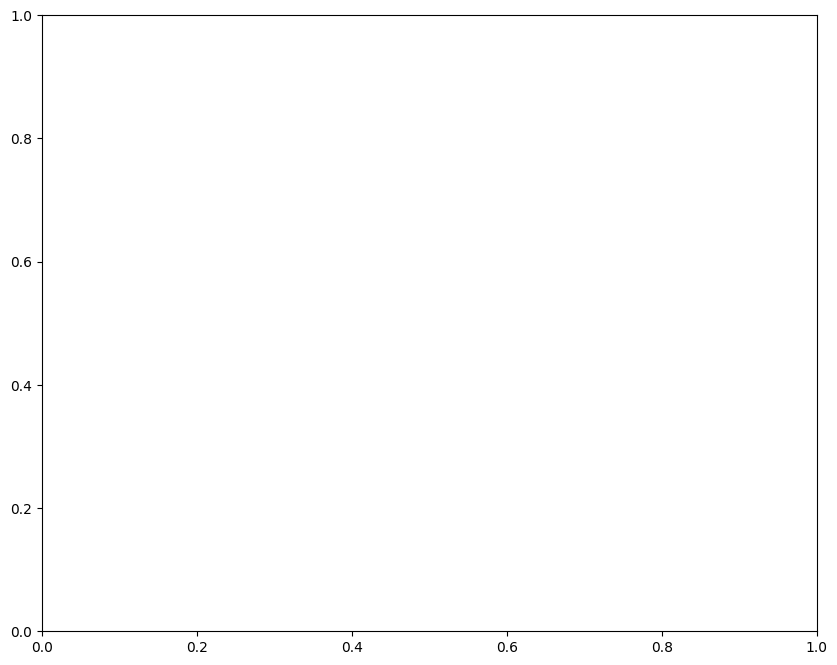

In [6]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LightSource

# Load the SRTM data for shading
shading_dataset = gdal.Open(r'../data/shading/srtm_slo_250.tif')
shading_band = shading_dataset.GetRasterBand(1)
shading_data = shading_band.ReadAsArray()

# Load your temperature data (replace this with your actual temperature data)
temperature_data = np.random.uniform(10, 30, shading_data.shape)  # Replace with your data

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Create a light source for shading to simulate 3D effect
ls = LightSource(azdeg=315, altdeg=45)

print(shading_data.shape)
cmap=plt.get_cmap('gist_earth')
# Apply shading to the SRTM data to make it look 3D
shaded_relief = ls.shade(shading_data, cmap=cmap, vert_exag=1.0, blend_mode='soft')

# Display the shaded SRTM data as the background
ax.imshow(shaded_relief, extent=[0, shading_data.shape[1], 0, shading_data.shape[0]], cmap=cmap, alpha=1.0)

# Define contour levels and colormap for temperature
temperature_levels = np.linspace(temperature_data.min(), temperature_data.max(), 20)
temperature_colormap = plt.get_cmap('coolwarm')

# Create temperature contours on top of the shaded relief
contour = ax.contourf(temperature_data, levels=temperature_levels, cmap=temperature_colormap, alpha=0.7)

# Add a colorbar for the temperature data
cbar_temperature = plt.colorbar(contour, ax=ax, label='Temperature (°C)')

# Customize your map as needed

# Save or display the resulting 2D map with a 3D-like appearance and temperature contours
plt.savefig('2DMapWith3DEffectAndTemperatureContours.png')
plt.show()


1
